# Step 3. EDA (탐색적 데이터 분석)

Step2에서 생성한 15개 파생 변수의 **시계열 패턴, 상관관계, 선행성**을 시각화하고,  
확장 Granger 인과 검정으로 포트폴리오 변동성에 대한 **선행 지표 랭킹**을 도출합니다.

In [1]:
# ============================================================
# 라이브러리 및 데이터 로드
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests
import os, warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 경로
DATA_DIR = os.path.join(os.getcwd(), 'data')
IMG_DIR  = os.path.join(os.getcwd(), 'images')
os.makedirs(IMG_DIR, exist_ok=True)

# 데이터 로드
df_reg = pd.read_csv(os.path.join(DATA_DIR, 'df_reg_v2.csv'),
                     index_col=0, parse_dates=True)
df_feat = pd.read_csv(os.path.join(DATA_DIR, 'features.csv'),
                      index_col=0, parse_dates=True)

print(f'df_reg_v2 : {df_reg.shape}')
print(f'features  : {df_feat.shape}')

df_reg_v2 : (1045, 34)
features  : (1304, 15)


## 3-1. 대안데이터 시계열 대시보드

4가지 리스크 채널을 한 눈에 파악할 수 있는 대시보드입니다.

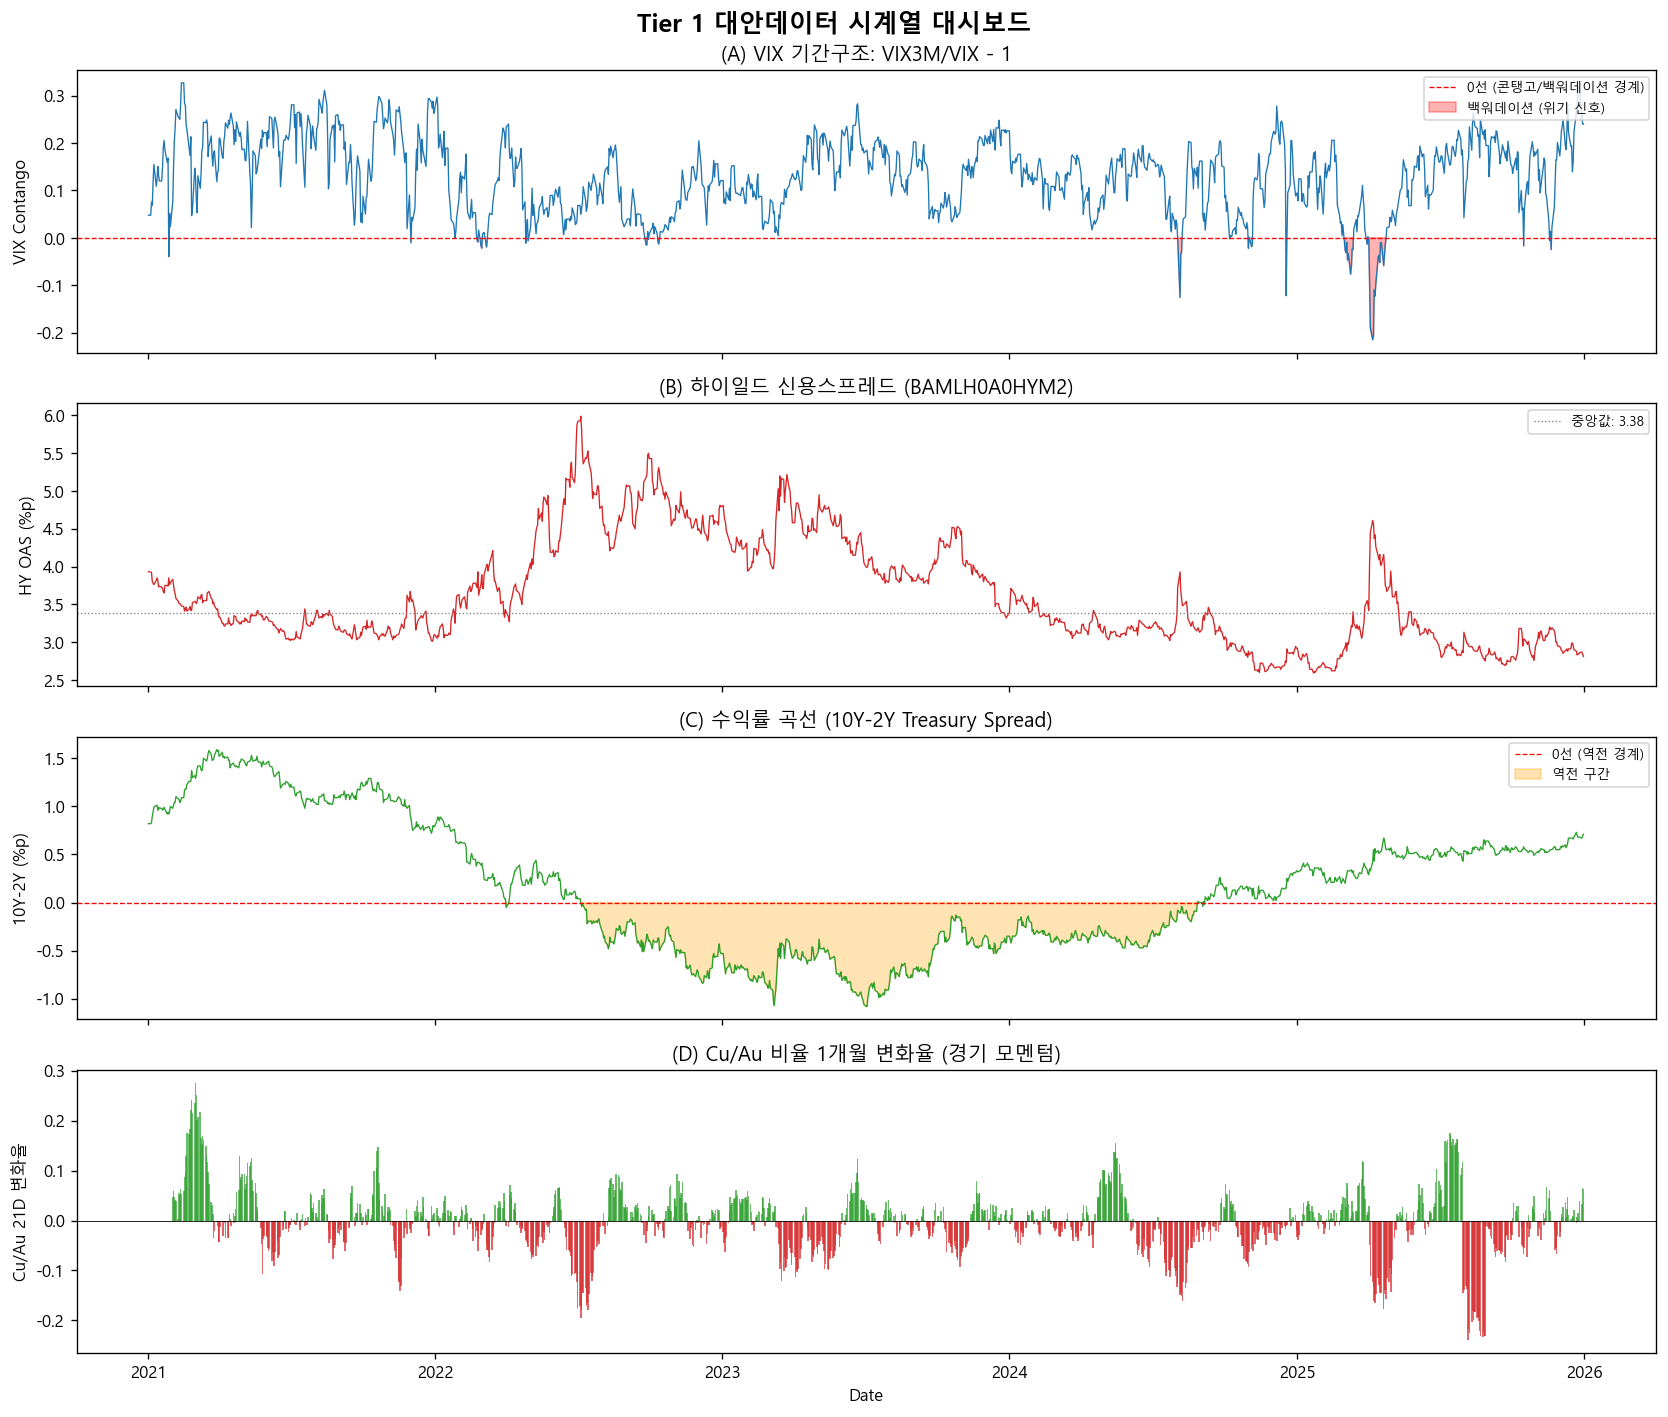

저장: images/eda_01_dashboard.png


In [2]:
# ============================================================
# 시계열 대시보드 (4채널)
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Tier 1 대안데이터 시계열 대시보드', fontsize=15, fontweight='bold')

# (A) VIX 기간구조: VIX_contango
ax = axes[0]
ax.plot(df_feat.index, df_feat['VIX_contango'], color='#1f77b4', linewidth=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='0선 (콘탱고/백워데이션 경계)')
ax.fill_between(df_feat.index, df_feat['VIX_contango'], 0,
                where=df_feat['VIX_contango'] < 0, color='red', alpha=0.3, label='백워데이션 (위기 신호)')
ax.set_ylabel('VIX Contango')
ax.set_title('(A) VIX 기간구조: VIX3M/VIX - 1')
ax.legend(loc='upper right', fontsize=8)

# (B) 신용 시장: HY 스프레드
ax = axes[1]
ax.plot(df_feat.index, df_feat['HY_spread'], color='#d62728', linewidth=0.8)
ax.axhline(df_feat['HY_spread'].median(), color='gray', linestyle=':', linewidth=0.8, label=f'중앙값: {df_feat["HY_spread"].median():.2f}')
ax.set_ylabel('HY OAS (%p)')
ax.set_title('(B) 하이일드 신용스프레드 (BAMLH0A0HYM2)')
ax.legend(loc='upper right', fontsize=8)

# (C) 수익률 곡선: T10Y2Y
ax = axes[2]
ax.plot(df_feat.index, df_feat['yield_curve'], color='#2ca02c', linewidth=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='0선 (역전 경계)')
ax.fill_between(df_feat.index, df_feat['yield_curve'], 0,
                where=df_feat['yield_curve'] < 0, color='orange', alpha=0.3, label='역전 구간')
ax.set_ylabel('10Y-2Y (%p)')
ax.set_title('(C) 수익률 곡선 (10Y-2Y Treasury Spread)')
ax.legend(loc='upper right', fontsize=8)

# (D) 실물 경기: Cu/Au 비율 변화
ax = axes[3]
cu_au = df_feat['Cu_Au_ratio_chg'].dropna()
ax.bar(cu_au.index, cu_au, width=2, color=np.where(cu_au >= 0, '#2ca02c', '#d62728'), alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Cu/Au 21D 변화율')
ax.set_title('(D) Cu/Au 비율 1개월 변화율 (경기 모멘텀)')
ax.set_xlabel('Date')

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'eda_01_dashboard.png'), bbox_inches='tight')
plt.show()
print('저장: images/eda_01_dashboard.png')

## 3-2. 확장 상관관계 히트맵

기존 7개 외부 지표 + 15개 신규 파생 변수 간의 상관관계를 시각화합니다.

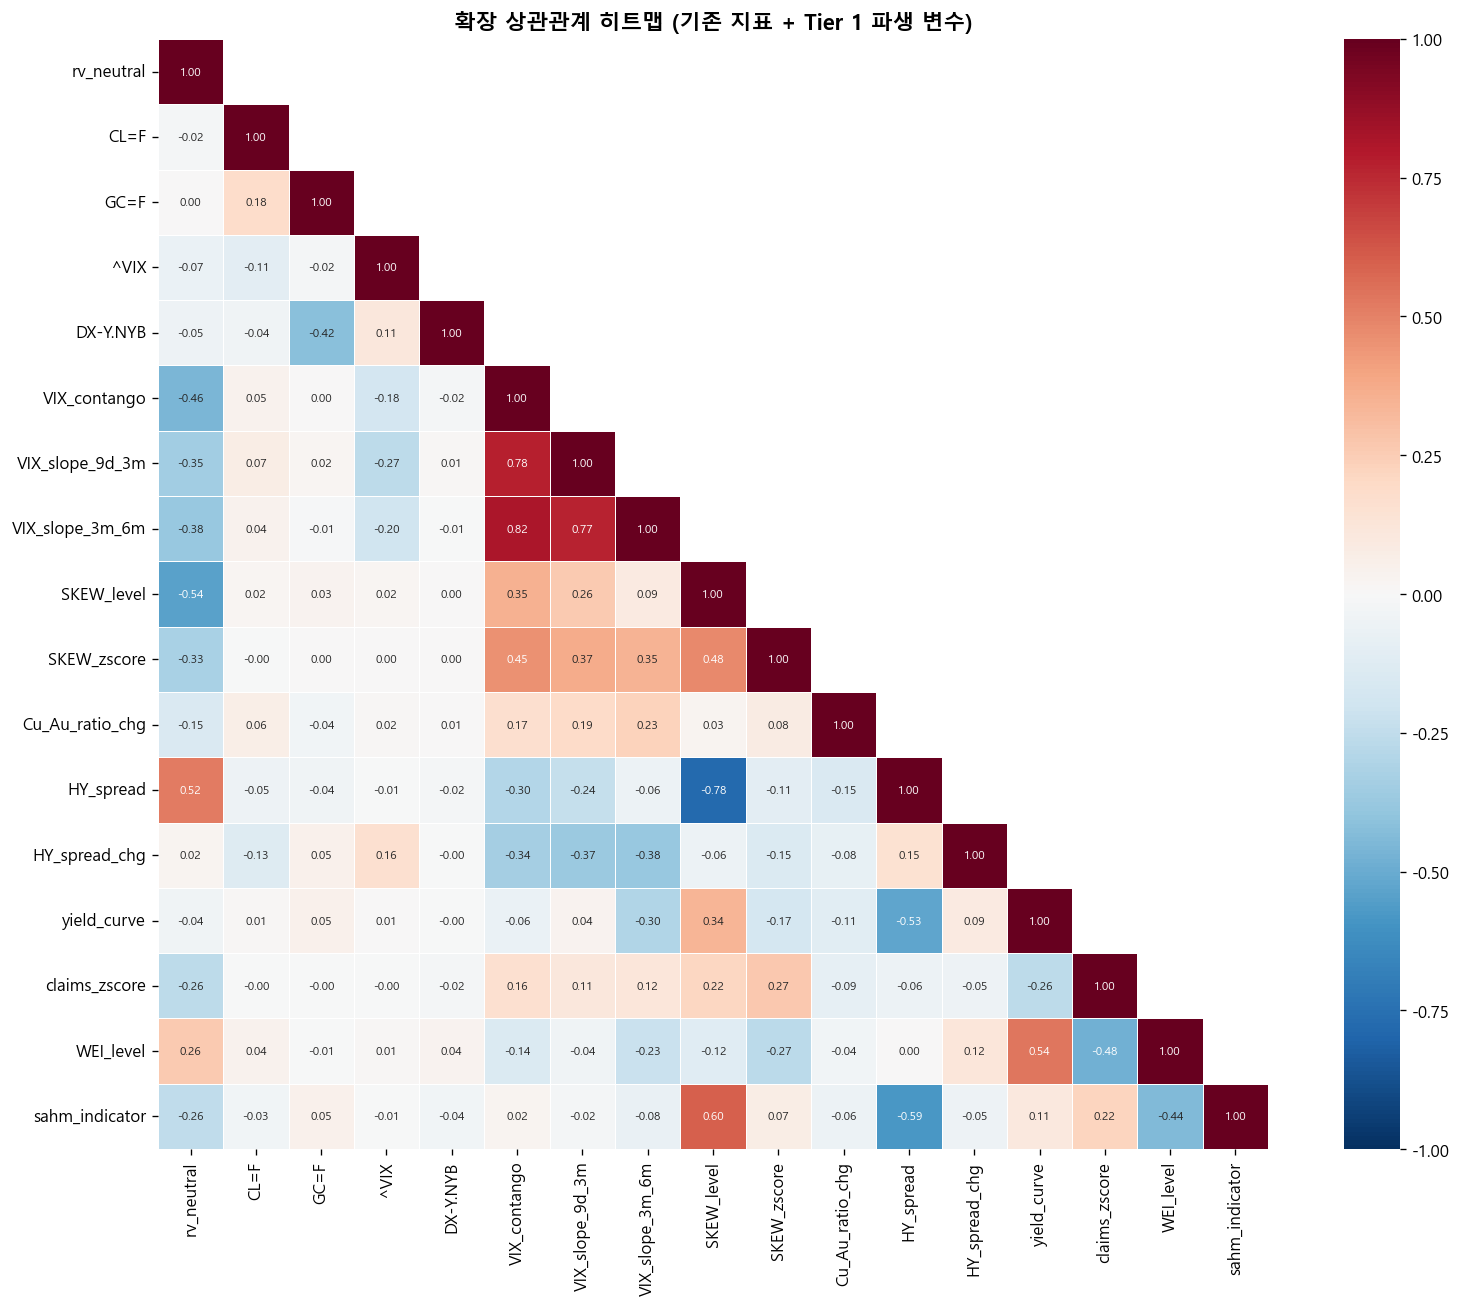

저장: images/eda_02_correlation.png


In [3]:
# ============================================================
# 확장 상관관계 히트맵
# ============================================================

# 주요 변수만 선택 (너무 많으면 히트맵 가독성 저하)
corr_cols = [
    # 타겟
    'rv_neutral',
    # 기존 외부 지표
    'CL=F', 'GC=F', '^VIX', 'DX-Y.NYB',
    # 신규 파생 변수
    'VIX_contango', 'VIX_slope_9d_3m', 'VIX_slope_3m_6m',
    'SKEW_level', 'SKEW_zscore',
    'Cu_Au_ratio_chg', 'HY_spread', 'HY_spread_chg',
    'yield_curve', 'claims_zscore', 'WEI_level', 'sahm_indicator',
]
# 실제 존재하는 컬럼만 사용
corr_cols = [c for c in corr_cols if c in df_reg.columns]

corr_matrix = df_reg[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # 상삼각 마스크
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, annot_kws={'size': 7}, ax=ax)
ax.set_title('확장 상관관계 히트맵 (기존 지표 + Tier 1 파생 변수)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'eda_02_correlation.png'), bbox_inches='tight')
plt.show()
print('저장: images/eda_02_correlation.png')

## 3-3. VIX vs VIX_contango 관계 분석

VIX 수준과 VIX 기간구조(콘탱고/백워데이션)의 관계를 산점도로 확인합니다.  
**핵심 가설**: 백워데이션(contango < 0)은 VIX 급등보다 선행하여 나타나는가?

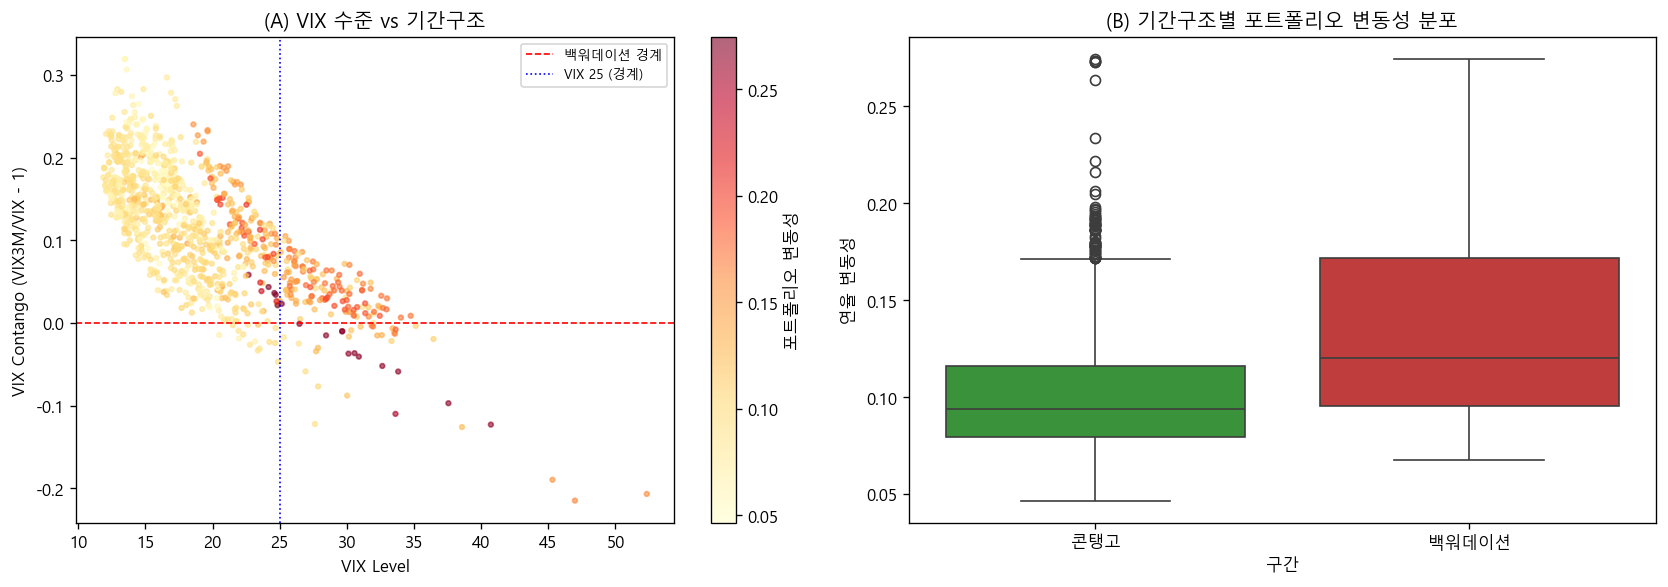

저장: images/eda_03_vix_contango.png


In [4]:
# ============================================================
# VIX 수준 vs 기간구조 산점도
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) VIX level vs VIX_contango 산점도
ax = axes[0]
sc = ax.scatter(df_reg['VIX_level'], df_reg['VIX_contango'],
                c=df_reg['rv_neutral'], cmap='YlOrRd', s=8, alpha=0.6)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='백워데이션 경계')
ax.axvline(25, color='blue', linestyle=':', linewidth=1, label='VIX 25 (경계)')
ax.set_xlabel('VIX Level')
ax.set_ylabel('VIX Contango (VIX3M/VIX - 1)')
ax.set_title('(A) VIX 수준 vs 기간구조')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='포트폴리오 변동성')

# (B) 백워데이션 구간에서의 5일 후 SPY 수익률
ax = axes[1]
spy_ret_5d = df_reg['CL=F'].rolling(5).sum()  # 원유 5일 누적 (예시)

# rv_neutral를 백워데이션 여부로 분류
is_backwardation = df_reg['VIX_contango'] < 0
data_box = pd.DataFrame({
    '포트폴리오 변동성': df_reg['rv_neutral'],
    '구간': np.where(is_backwardation, '백워데이션', '콘탱고')
})
sns.boxplot(data=data_box, x='구간', y='포트폴리오 변동성', ax=ax,
            palette={'콘탱고': '#2ca02c', '백워데이션': '#d62728'})
ax.set_title('(B) 기간구조별 포트폴리오 변동성 분포')
ax.set_ylabel('연율 변동성')

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'eda_03_vix_contango.png'), bbox_inches='tight')
plt.show()
print('저장: images/eda_03_vix_contango.png')

## 3-4. 수익률 곡선 역전 타임라인

10Y-2Y 스프레드의 역전 구간을 시각화하고, 포트폴리오 변동성과의 관계를 확인합니다.

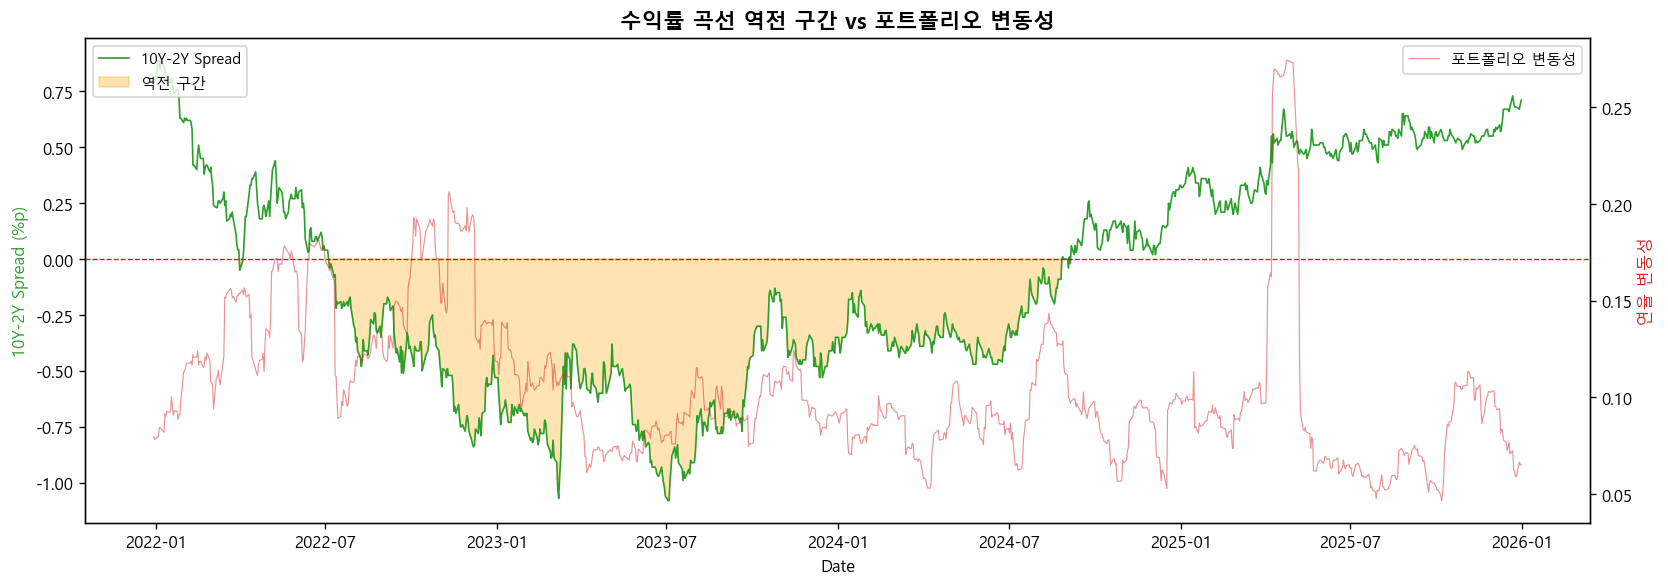

저장: images/eda_04_yield_curve.png


In [5]:
# ============================================================
# 수익률 곡선 역전 타임라인 + 변동성 오버레이
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 5))

# 수익률 곡선
ax1.plot(df_reg.index, df_reg['yield_curve'], color='#2ca02c', linewidth=1, label='10Y-2Y Spread')
ax1.fill_between(df_reg.index, df_reg['yield_curve'], 0,
                 where=df_reg['yield_curve'] < 0, color='orange', alpha=0.3, label='역전 구간')
ax1.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax1.set_ylabel('10Y-2Y Spread (%p)', color='#2ca02c')
ax1.set_xlabel('Date')
ax1.legend(loc='upper left', fontsize=9)

# 변동성 오버레이 (보조 축)
ax2 = ax1.twinx()
ax2.plot(df_reg.index, df_reg['rv_neutral'], color='#d62728', alpha=0.5, linewidth=0.7, label='포트폴리오 변동성')
ax2.set_ylabel('연율 변동성', color='#d62728')
ax2.legend(loc='upper right', fontsize=9)

ax1.set_title('수익률 곡선 역전 구간 vs 포트폴리오 변동성', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'eda_04_yield_curve.png'), bbox_inches='tight')
plt.show()
print('저장: images/eda_04_yield_curve.png')

## 3-5. 주간 매크로 Nowcasting 시계열

실업수당(ICSA), Weekly Economic Index(WEI), Sahm Rule 지표를 함께 시각화합니다.

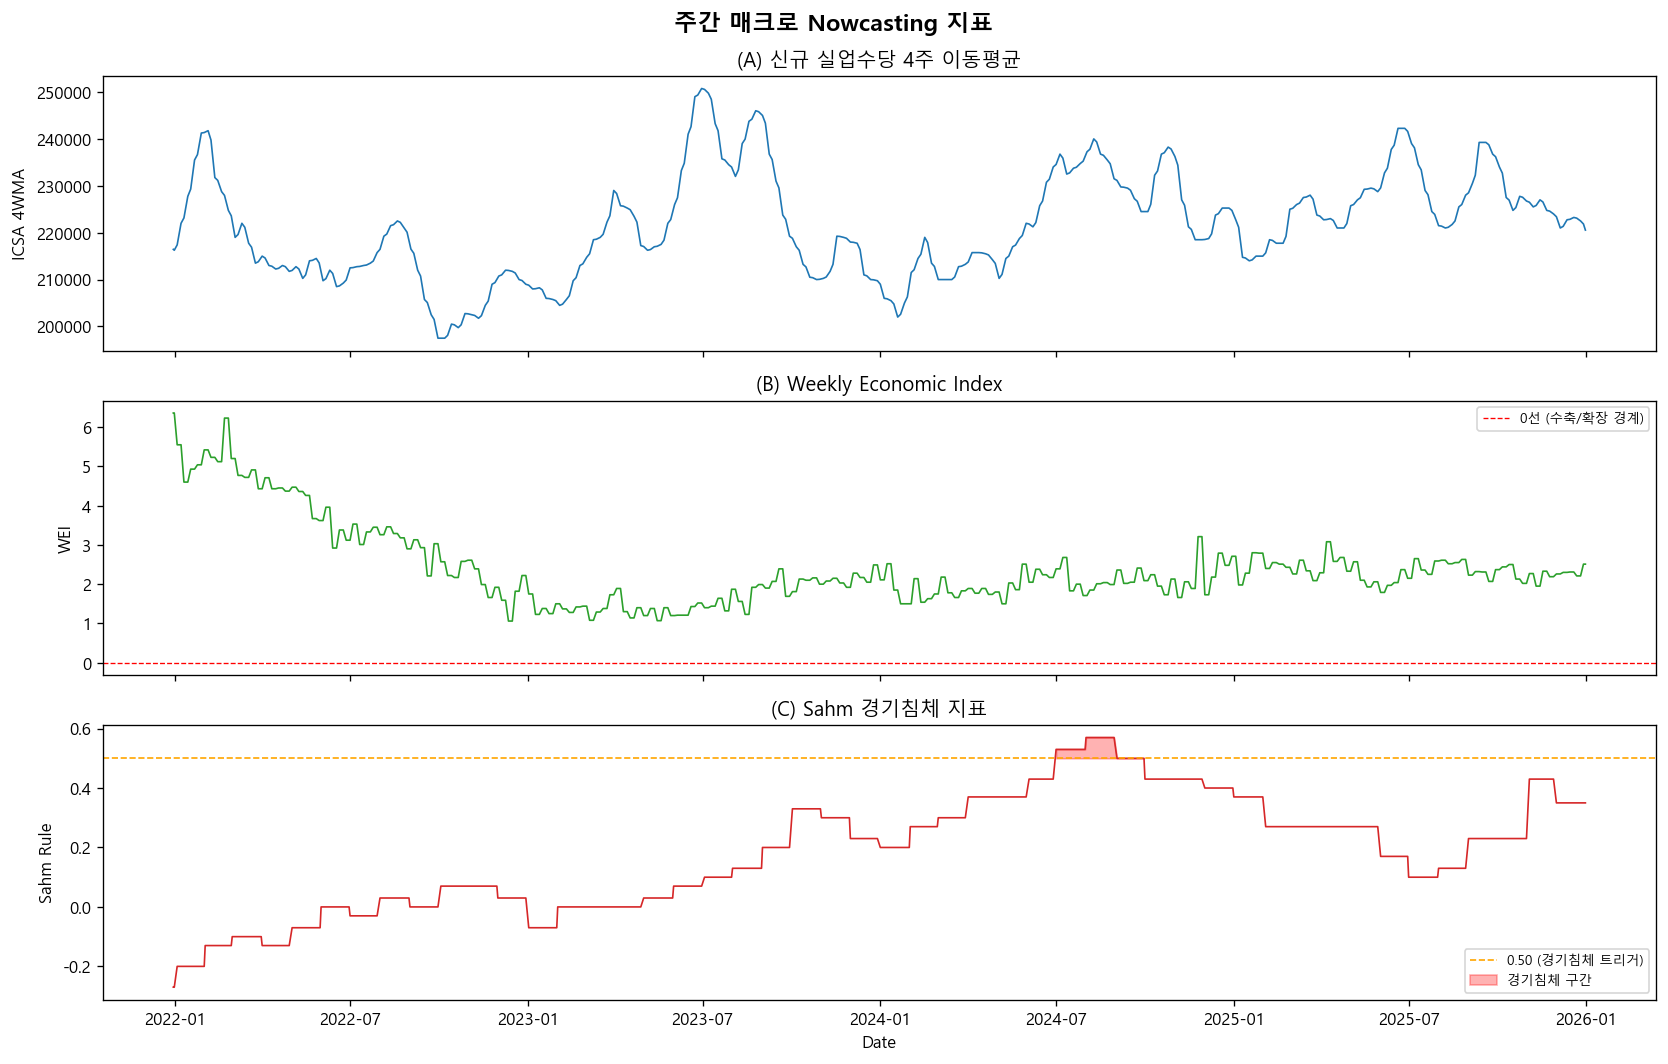

저장: images/eda_05_macro_nowcast.png


In [6]:
# ============================================================
# 주간 매크로 Nowcasting 시계열
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('주간 매크로 Nowcasting 지표', fontsize=14, fontweight='bold')

# (A) 실업수당 4주 이동평균
ax = axes[0]
ax.plot(df_reg.index, df_reg['claims_4wma'], color='#1f77b4', linewidth=1)
ax.set_ylabel('ICSA 4WMA')
ax.set_title('(A) 신규 실업수당 4주 이동평균')

# (B) Weekly Economic Index
ax = axes[1]
ax.plot(df_reg.index, df_reg['WEI_level'], color='#2ca02c', linewidth=1)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='0선 (수축/확장 경계)')
ax.set_ylabel('WEI')
ax.set_title('(B) Weekly Economic Index')
ax.legend(fontsize=8)

# (C) Sahm 경기침체 지표
ax = axes[2]
ax.plot(df_reg.index, df_reg['sahm_indicator'], color='#d62728', linewidth=1)
ax.axhline(0.5, color='orange', linestyle='--', linewidth=1, label='0.50 (경기침체 트리거)')
ax.fill_between(df_reg.index, df_reg['sahm_indicator'], 0.5,
                where=df_reg['sahm_indicator'] >= 0.5, color='red', alpha=0.3, label='경기침체 구간')
ax.set_ylabel('Sahm Rule')
ax.set_title('(C) Sahm 경기침체 지표')
ax.set_xlabel('Date')
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'eda_05_macro_nowcast.png'), bbox_inches='tight')
plt.show()
print('저장: images/eda_05_macro_nowcast.png')

## 3-6. 확장 Granger 인과 검정

기존 7개 외부 지표 + 15개 신규 파생 변수가 **포트폴리오 실현 변동성(rv_neutral)을 선행 예측**하는지 검정합니다.  
lag 1~10에서 F-검정의 최소 p-value를 기준으로 유의성을 판단합니다.

In [7]:
# ============================================================
# 확장 Granger 인과 검정
# ============================================================

# 검정 대상: rv_neutral을 제외한 모든 수치형 컬럼
target = 'rv_neutral'
candidates = [c for c in df_reg.columns
              if c != target and df_reg[c].dtype in ['float64', 'int64']]

granger_results = []

for col in candidates:
    try:
        # Granger 검정용 데이터: [타겟(y), 원인 후보(x)] 순서
        test_data = df_reg[[target, col]].dropna()
        if len(test_data) < 50:  # 최소 관측치
            continue

        result = grangercausalitytests(test_data, maxlag=10, verbose=False)

        # 각 lag에서 F-검정 p-value 추출 → 최소 p-value와 해당 lag 선택
        best_pval = 1.0
        best_lag  = 0
        for lag in range(1, 11):
            pval = result[lag][0]['ssr_ftest'][1]
            if pval < best_pval:
                best_pval = pval
                best_lag  = lag

        granger_results.append({
            '변수': col,
            '최적 lag': best_lag,
            'p-value': best_pval,
            '유의(5%)': best_pval < 0.05,
        })
    except Exception:
        pass  # 정상적이지 않은 시리즈 건너뜀

# 결과 정리
df_granger = pd.DataFrame(granger_results).sort_values('p-value')
df_granger = df_granger.reset_index(drop=True)

print(f'Granger 검정 완료: {len(df_granger)}개 변수')
print(f'유의한 선행지표 (p < 0.05): {df_granger["유의(5%)"].sum()}개')
print()
print(df_granger.head(20).to_string(index=False))

Granger 검정 완료: 33개 변수
유의한 선행지표 (p < 0.05): 25개

             변수  최적 lag      p-value  유의(5%)
        RV_SI=F       8 2.642055e-18    True
VIX_slope_9d_3m       1 5.484832e-16    True
      VIX_level       1 2.726286e-13    True
VIX_slope_3m_6m       1 6.529704e-11    True
  HY_spread_chg       1 3.632124e-09    True
   VIX_contango       1 2.645075e-08    True
      HY_spread       5 1.419360e-07    True
        RV_^VIX       4 2.562139e-06    True
         UNRATE       8 1.247601e-05    True
        RV_CL=F       5 2.746241e-05    True
           ^VIX       7 1.536126e-04    True
        ETH-USD       2 2.246166e-04    True
        RV_GC=F       5 2.568764e-04    True
    RV_DX-Y.NYB      10 2.602019e-04    True
      WEI_level       3 8.443990e-04    True
    SKEW_zscore       1 4.073712e-03    True
        BTC-USD       1 4.961856e-03    True
Cu_Au_ratio_chg      10 1.477770e-02    True
          DGS10       9 1.677163e-02    True
     RV_ETH-USD       3 1.703332e-02    True


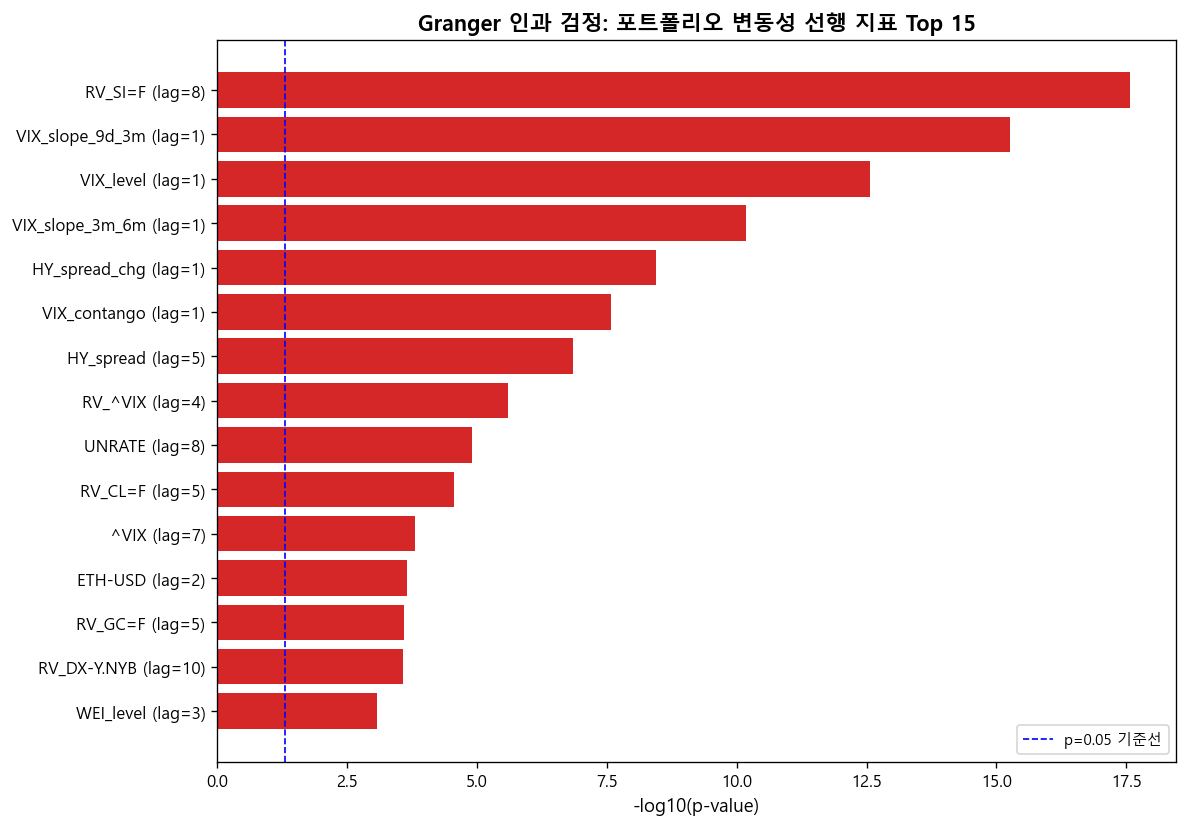

저장: images/eda_06_granger.png
저장: data/granger_results.csv


In [8]:
# ============================================================
# Granger 유의 선행지표 시각화
# ============================================================

# 상위 15개 (p-value 기준)
top15 = df_granger.head(15).copy()
top15['neg_log_p'] = -np.log10(top15['p-value'].clip(lower=1e-20))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if sig else '#aaaaaa' for sig in top15['유의(5%)']]
bars = ax.barh(range(len(top15)), top15['neg_log_p'], color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([f"{row['변수']} (lag={row['최적 lag']})" for _, row in top15.iterrows()])
ax.axvline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1, label='p=0.05 기준선')
ax.set_xlabel('-log10(p-value)', fontsize=11)
ax.set_title('Granger 인과 검정: 포트폴리오 변동성 선행 지표 Top 15', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'eda_06_granger.png'), bbox_inches='tight')
plt.show()
print('저장: images/eda_06_granger.png')

# Granger 결과 CSV 저장 (Step4, Step5에서 활용)
df_granger.to_csv(os.path.join(DATA_DIR, 'granger_results.csv'), index=False)
print('저장: data/granger_results.csv')